In [1]:
!pip install ultralytics opencv-python numpy matplotlib pyrealsense2


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [3]:
try:
    import pyrealsense2 as rs
    REALSENSE_AVAILABLE = True
except:
    REALSENSE_AVAILABLE = False

In [26]:
import os
import cv2
import time
import numpy as np
from ultralytics import YOLO


class Vision:

    def __init__(self, dataset_path=r"C:\Users\HP\Downloads\rgbd_dataset_freiburg1_xyz",
                 conf_threshold=0.5):

        # Load YOLO model
        self.model = YOLO("yolov8n.pt")

        # Dataset paths
        self.dataset_path = dataset_path
        self.rgb_path = os.path.join(dataset_path, "rgb")
        self.depth_path = os.path.join(dataset_path, "depth")

        self.rgb_files = sorted(os.listdir(self.rgb_path))
        self.depth_files = sorted(os.listdir(self.depth_path))

        self.index = 0

        self.conf_threshold = conf_threshold

        # Object tracking memory
        self.tracked_objects = {}
        self.next_id = 0

        # Camera intrinsics (approximate for TUM dataset)
        self.fx = 525.0
        self.fy = 525.0
        self.cx = 319.5
        self.cy = 239.5

        self.last_time = time.time()

    # --------------------------------------------------
    # Load RGB + Depth frames
    # --------------------------------------------------

    def get_frames(self):

        if self.index >= len(self.rgb_files):
            self.index = 0

        rgb_file = os.path.join(self.rgb_path, self.rgb_files[self.index])
        depth_file = os.path.join(self.depth_path, self.depth_files[self.index])

        color = cv2.imread(rgb_file)
        depth = cv2.imread(depth_file, cv2.IMREAD_UNCHANGED)

        self.index += 1

        return color, depth

    # --------------------------------------------------
    # Robust depth estimation
    # --------------------------------------------------

    def get_depth(self, depth, cx, cy):

        h, w = depth.shape

        x1 = max(cx - 2, 0)
        x2 = min(cx + 3, w)
        y1 = max(cy - 2, 0)
        y2 = min(cy + 3, h)

        window = depth[y1:y2, x1:x2]

        if window.size == 0:
            return 0

        valid = window[window > 0]

        if len(valid) == 0:
            return 0

        z = np.median(valid) / 5000.0
        return z

    # --------------------------------------------------
    # Convert pixel to 3D coordinates
    # --------------------------------------------------

    def pixel_to_3d(self, u, v, z):

        x = (u - self.cx) * z / self.fx
        y = (v - self.cy) * z / self.fy

        return (x, y, z)

    # --------------------------------------------------
    # Simple object tracker
    # --------------------------------------------------

    def assign_id(self, label, position):

        best_id = None
        best_dist = 999

        for obj_id, obj in self.tracked_objects.items():

            if obj["label"] != label:
                continue

            prev_pos = obj["position"]

            dist = np.linalg.norm(np.array(prev_pos) - np.array(position))

            if dist < best_dist and dist < 0.5:
                best_dist = dist
                best_id = obj_id

        if best_id is None:
            best_id = self.next_id
            self.next_id += 1

        self.tracked_objects[best_id] = {
            "label": label,
            "position": position,
            "last_seen": time.time()
        }

        return best_id

    # --------------------------------------------------
    # Detection
    # --------------------------------------------------

    def detect(self, color, depth):

        results = self.model(color, verbose=False)

        detections = []
        annotated = color.copy()

        for r in results:

            for box in r.boxes:

                confidence = float(box.conf[0])

                if confidence < self.conf_threshold:
                    continue

                cls_id = int(box.cls[0])
                label = self.model.names[cls_id]

                x1, y1, x2, y2 = map(int, box.xyxy[0])

                cx_pixel = int((x1 + x2) / 2)
                cy_pixel = int((y1 + y2) / 2)

                z = self.get_depth(depth, cx_pixel, cy_pixel)

                if z <= 0:
                    continue

                # Convert to 3D
                position_3d = self.pixel_to_3d(cx_pixel, cy_pixel, z)

                # Assign tracking ID
                obj_id = self.assign_id(label, position_3d)

                detections.append({
                    "id": obj_id,
                    "object": label,
                    "confidence": confidence,
                    "position": position_3d,
                    "timestamp": time.time()
                })

                # Draw bounding box
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (0,255,0), 2)

                text = f"{label} | ID:{obj_id} | {z:.2f}m"

                cv2.putText(
                    annotated,
                    text,
                    (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,0),
                    2
                )

        # FPS calculation
        now = time.time()
        fps = 1 / (now - self.last_time)
        self.last_time = now

        cv2.putText(
            annotated,
            f"FPS: {fps:.2f}",
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,0,255),
            2
        )

        return detections, annotated

[{'id': 0, 'object': 'person', 'confidence': 0.9269422888755798, 'position': (-0.12472038095238093, -0.7588918095238094, 2.2196), 'timestamp': 1772638170.592975}, {'id': 1, 'object': 'keyboard', 'confidence': 0.8651776909828186, 'position': (0.2711761904761905, 0.31653657142857144, 1.0354), 'timestamp': 1772638170.592975}, {'id': 2, 'object': 'mouse', 'confidence': 0.854703962802887, 'position': (0.5385988571428572, 0.21823466666666666, 1.1288), 'timestamp': 1772638170.592975}, {'id': 3, 'object': 'book', 'confidence': 0.7263643741607666, 'position': (-0.5870794285714286, 0.142868, 1.2606), 'timestamp': 1772638170.5939775}, {'id': 4, 'object': 'tv', 'confidence': 0.6905906796455383, 'position': (0.25783219047619044, -0.07925580952380952, 1.0534), 'timestamp': 1772638170.5942957}, {'id': 5, 'object': 'chair', 'confidence': 0.6582366228103638, 'position': (-1.385190476190476, -0.9360971428571427, 3.062), 'timestamp': 1772638170.5942957}, {'id': 6, 'object': 'cup', 'confidence': 0.6015199

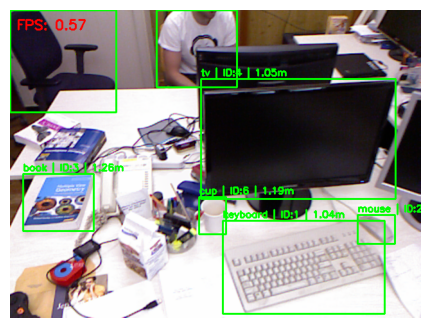

[{'id': 0, 'object': 'person', 'confidence': 0.9254632592201233, 'position': (-0.10712914285714287, -0.7667085714285714, 2.2056), 'timestamp': 1772638170.8419707}, {'id': 2, 'object': 'mouse', 'confidence': 0.8648906946182251, 'position': (0.548744761904762, 0.20777714285714285, 1.1188), 'timestamp': 1772638170.8419707}, {'id': 1, 'object': 'keyboard', 'confidence': 0.8622592687606812, 'position': (0.280276, 0.3037137142857143, 1.0254), 'timestamp': 1772638170.8429701}, {'id': 5, 'object': 'chair', 'confidence': 0.7884697914123535, 'position': (-1.3735257142857142, -0.9477619047619047, 3.062), 'timestamp': 1772638170.8429701}, {'id': 3, 'object': 'book', 'confidence': 0.7659874558448792, 'position': (-0.5823592380952382, 0.1303432380952381, 1.2556), 'timestamp': 1772638170.8429701}, {'id': 4, 'object': 'tv', 'confidence': 0.5454326272010803, 'position': (0.27274761904761907, -0.08827104761904762, 1.0414), 'timestamp': 1772638170.843724}]


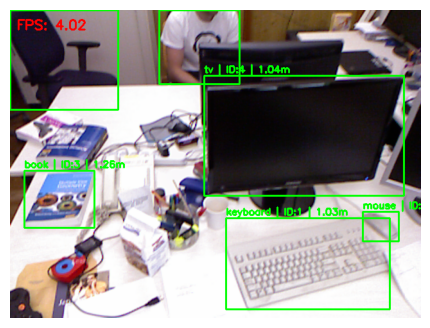

[{'id': 1, 'object': 'keyboard', 'confidence': 0.9306366443634033, 'position': (0.28852076190476195, 0.2923805714285715, 1.0132), 'timestamp': 1772638171.075507}, {'id': 0, 'object': 'person', 'confidence': 0.9253047108650208, 'position': (-0.08921066666666666, -0.7738506666666666, 2.1784), 'timestamp': 1772638171.0765057}, {'id': 2, 'object': 'mouse', 'confidence': 0.8421032428741455, 'position': (0.5540024761904762, 0.19237657142857142, 1.1038), 'timestamp': 1772638171.0765057}, {'id': 3, 'object': 'book', 'confidence': 0.7635860443115234, 'position': (-0.575184380952381, 0.11121028571428572, 1.2556), 'timestamp': 1772638171.0765057}, {'id': 7, 'object': 'chair', 'confidence': 0.7174881100654602, 'position': (-1.167452, -0.8204386666666665, 2.6026), 'timestamp': 1772638171.0775084}, {'id': 6, 'object': 'cup', 'confidence': 0.707187294960022, 'position': (0.0077066666666666655, 0.15083047619047618, 1.156), 'timestamp': 1772638171.0775084}, {'id': 4, 'object': 'tv', 'confidence': 0.629

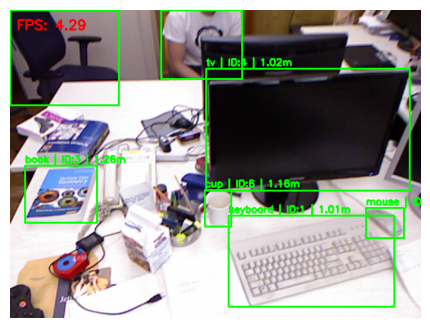

[{'id': 1, 'object': 'keyboard', 'confidence': 0.9335228204727173, 'position': (0.2902438095238095, 0.2902438095238095, 0.9992), 'timestamp': 1772638171.324325}, {'id': 8, 'object': 'person', 'confidence': 0.8727838397026062, 'position': (-0.044597333333333336, -0.4544106666666667, 1.2656), 'timestamp': 1772638171.324325}, {'id': 2, 'object': 'mouse', 'confidence': 0.8540215492248535, 'position': (0.5598413333333333, 0.17968933333333334, 1.0906), 'timestamp': 1772638171.324325}, {'id': 5, 'object': 'chair', 'confidence': 0.8158790469169617, 'position': (-1.349852380952381, -0.9683095238095238, 3.035), 'timestamp': 1772638171.325407}, {'id': 6, 'object': 'cup', 'confidence': 0.7871917486190796, 'position': (0.011984761904761904, 0.1383695238095238, 1.144), 'timestamp': 1772638171.325407}, {'id': 3, 'object': 'book', 'confidence': 0.7382022142410278, 'position': (-0.5685958095238095, 0.09852495238095238, 1.2464), 'timestamp': 1772638171.325407}, {'id': 4, 'object': 'tv', 'confidence': 0.

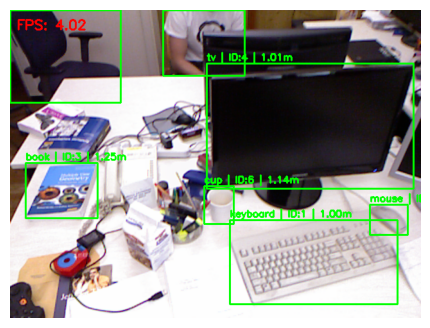

[{'id': 1, 'object': 'keyboard', 'confidence': 0.9059551358222961, 'position': (0.29737619047619046, 0.2786142857142857, 0.985), 'timestamp': 1772638171.560933}, {'id': 2, 'object': 'mouse', 'confidence': 0.8508477210998535, 'position': (0.562908, 0.17123066666666667, 1.0766), 'timestamp': 1772638171.560933}, {'id': 8, 'object': 'person', 'confidence': 0.7832916378974915, 'position': (-0.03694609523809524, -0.45884666666666674, 1.2514), 'timestamp': 1772638171.560933}, {'id': 5, 'object': 'chair', 'confidence': 0.7811329364776611, 'position': (-1.3560285714285714, -0.9944209523809524, 3.062), 'timestamp': 1772638171.560933}, {'id': 6, 'object': 'cup', 'confidence': 0.7549667358398438, 'position': (0.014025142857142858, 0.1305417142857143, 1.1328), 'timestamp': 1772638171.562041}, {'id': 3, 'object': 'book', 'confidence': 0.7519658803939819, 'position': (-0.5590158095238095, 0.09453085714285715, 1.2254), 'timestamp': 1772638171.562041}, {'id': 4, 'object': 'tv', 'confidence': 0.55478715

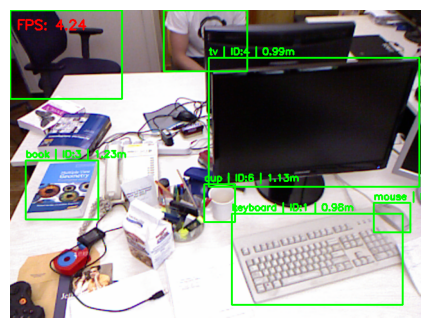

[{'id': 1, 'object': 'keyboard', 'confidence': 0.9296579957008362, 'position': (0.30518666666666666, 0.26808190476190474, 0.974), 'timestamp': 1772638171.792017}, {'id': 5, 'object': 'chair', 'confidence': 0.821519136428833, 'position': (-1.3560285714285714, -0.9944209523809524, 3.062), 'timestamp': 1772638171.792017}, {'id': 6, 'object': 'cup', 'confidence': 0.7268508672714233, 'position': (0.022576, 0.12578057142857144, 1.1288), 'timestamp': 1772638171.792017}, {'id': 3, 'object': 'book', 'confidence': 0.6926587820053101, 'position': (-0.5549100952380952, 0.08920266666666665, 1.2164), 'timestamp': 1772638171.7930143}, {'id': 8, 'object': 'person', 'confidence': 0.6146060228347778, 'position': (-0.04141333333333333, -0.4579131428571428, 1.2424), 'timestamp': 1772638171.7930143}, {'id': 4, 'object': 'tv', 'confidence': 0.52291339635849, 'position': (0.28997047619047617, -0.12773619047619048, 0.979), 'timestamp': 1772638171.7930143}]


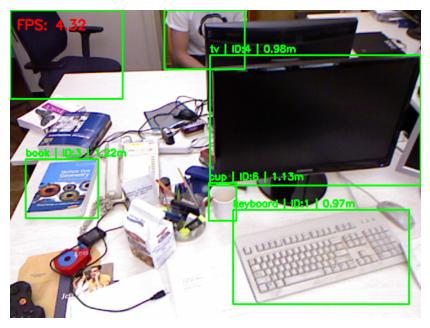

[{'id': 1, 'object': 'keyboard', 'confidence': 0.8910244107246399, 'position': (0.3046904761904762, 0.27194761904761905, 0.955), 'timestamp': 1772638172.027568}, {'id': 6, 'object': 'cup', 'confidence': 0.7518962621688843, 'position': (0.026542857142857142, 0.1199737142857143, 1.1148), 'timestamp': 1772638172.027568}, {'id': 5, 'object': 'chair', 'confidence': 0.7244933843612671, 'position': (-1.3382904761904764, -0.9914333333333334, 3.035), 'timestamp': 1772638172.027568}, {'id': 3, 'object': 'book', 'confidence': 0.670782208442688, 'position': (-0.5488679999999999, 0.08399866666666667, 1.2082), 'timestamp': 1772638172.027568}, {'id': 4, 'object': 'tv', 'confidence': 0.6333606839179993, 'position': (0.28796, -0.13524, 0.966), 'timestamp': 1772638172.0295746}]


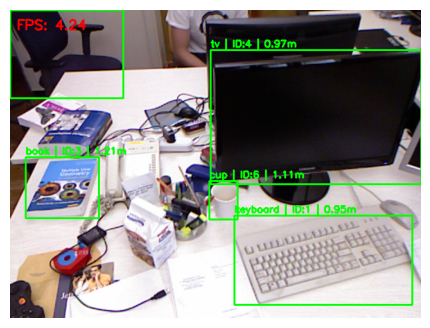

[{'id': 1, 'object': 'keyboard', 'confidence': 0.8943521976470947, 'position': (0.3185742857142857, 0.26048666666666664, 0.953), 'timestamp': 1772638172.2819788}, {'id': 6, 'object': 'cup', 'confidence': 0.7027310132980347, 'position': (0.03048590476190476, 0.11458495238095237, 1.1038), 'timestamp': 1772638172.2829845}, {'id': 5, 'object': 'chair', 'confidence': 0.6791890859603882, 'position': (-1.3325095238095237, -1.002995238095238, 3.035), 'timestamp': 1772638172.2829845}, {'id': 3, 'object': 'book', 'confidence': 0.635283887386322, 'position': (-0.5406857142857143, 0.07854171428571428, 1.1952), 'timestamp': 1772638172.2829845}, {'id': 4, 'object': 'tv', 'confidence': 0.5878657698631287, 'position': (0.28468095238095237, -0.13733809523809523, 0.955), 'timestamp': 1772638172.2839847}]


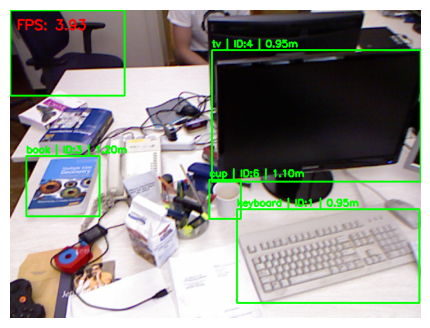

[{'id': 1, 'object': 'keyboard', 'confidence': 0.909099280834198, 'position': (0.31943238095238097, 0.2420487619047619, 0.9448), 'timestamp': 1772638172.535269}, {'id': 6, 'object': 'cup', 'confidence': 0.7838990688323975, 'position': (0.04242914285714286, 0.10038114285714285, 1.0866), 'timestamp': 1772638172.535269}, {'id': 0, 'object': 'person', 'confidence': 0.7063416838645935, 'position': (-0.1542230476190476, -0.7828283809523809, 2.0498), 'timestamp': 1772638172.535269}, {'id': 3, 'object': 'book', 'confidence': 0.6788885593414307, 'position': (-0.5379268571428572, 0.06053104761904762, 1.1992), 'timestamp': 1772638172.535269}, {'id': 5, 'object': 'chair', 'confidence': 0.6545346975326538, 'position': (-1.3038222857142858, -1.014084, 2.9826), 'timestamp': 1772638172.5362682}, {'id': 4, 'object': 'tv', 'confidence': 0.5193971395492554, 'position': (0.28043999999999997, -0.14867771428571427, 0.9348), 'timestamp': 1772638172.5362682}]


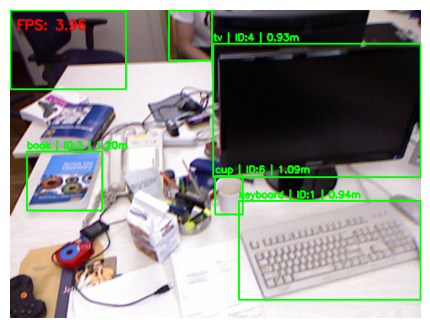

[{'id': 1, 'object': 'keyboard', 'confidence': 0.9022263884544373, 'position': (0.3185868571428571, 0.22806914285714286, 0.9318), 'timestamp': 1772638172.7795444}, {'id': 6, 'object': 'cup', 'confidence': 0.7448115348815918, 'position': (0.045840000000000006, 0.082512, 1.0696), 'timestamp': 1772638172.7795444}, {'id': 5, 'object': 'chair', 'confidence': 0.6142120957374573, 'position': (-1.2981411428571428, -1.0311274285714287, 2.9826), 'timestamp': 1772638172.7805383}, {'id': 3, 'object': 'book', 'confidence': 0.5476248860359192, 'position': (-0.5361325714285714, 0.04211657142857143, 1.1952), 'timestamp': 1772638172.7805383}, {'id': 4, 'object': 'tv', 'confidence': 0.5143429636955261, 'position': (0.27731733333333336, -0.16951999999999998, 0.9128), 'timestamp': 1772638172.7805383}]


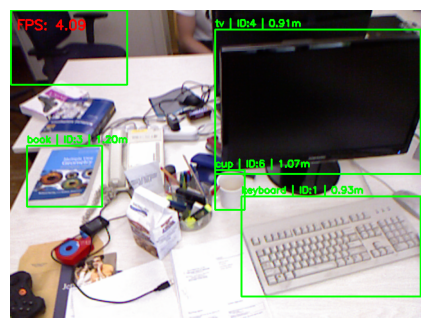

In [27]:
import matplotlib.pyplot as plt

vision = Vision()

for i in range(10):

    color, depth = vision.get_frames()

    detections, frame = vision.detect(color, depth)

    print(detections)

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()